### 1) Setup & imports

1. `import numpy as np`, `import pandas as pd`, `import matplotlib.pyplot as plt`

   * **What:** bring in core libs for arrays, dataframes and plotting.
   * **Why:** these are the basic tools for data handling and visualization.

2. `from sklearn...` imports (scalers, models, metrics, train_test_split)

   * **What:** load preprocessing, model classes, and evaluation functions.
   * **Why:** scikit-learn gives standardized APIs for training, predicting, and scoring.

---

### 2) Load the CSV and rename columns

1. `df = pd.read_csv(file_path)`

   * **What:** read the dataset file into a pandas DataFrame.

2. `df.rename({...}, inplace=True)`

   * **What:** replace short column names `X1..Y2` with descriptive names like `Relative Compactness`, `Heating Load`.
   * **Why:** readable column names make plotting, interpretation and debugging much easier.

3. `display(df.head())`, `df.describe()`

   * **What:** quick look at first rows and summary stats (mean, std, min, max).
   * **Why:** sanity checks — ensures the file loaded properly and shows feature ranges / outliers.

---

### 3) Exploratory Data Analysis (EDA)

1. **Histograms** of features & targets (`df[features + ['Heating Load', ...']].hist(...)`)

   * **What:** draws frequency distributions for each column.
   * **Why:** shows skewness, multi-modality, outliers, and scale differences between features.

2. **Scatter plots**: each feature vs Heating Load & v.s Cooling Load (`axes[i].scatter(...)`)

   * **What:** visualize pairwise relationships between each input feature and a target.
   * **Why:** helps spot linear or nonlinear relationships, clusters, or no relation. This guides model choice (linear vs tree-based).

---

### 4) Prepare features and targets

1. `features = [...]` list of the 8 predictor column names.

   * **Why:** consistent ordering is essential (manual input must match this order).

2. `X = df[features].values` and `y_heating = df['Heating Load'].values`, `y_cooling = ...`

   * **What:** separate predictors (X) and targets (y).
   * **Why:** standard supervised learning data layout.

---

### 5) Feature scaling

1. `scaler = StandardScaler(); X_scaled = scaler.fit_transform(X)`

   * **What:** mean-zero, unit-variance scaling (z-score).
   * **Why:** many algorithms — especially ones with regularization (Ridge, Lasso) or gradient-based training — work better when features are on similar scales. Tree models *don’t need* scaling, but we keep a single pipeline and scale anyway (no harm).

2. Keep the fitted `scaler` to later transform new/manual inputs the same way — important to apply *exactly* the same transformation.

---

### 6) Train / test split

1. `train_test_split(X_scaled, y, test_size=0.2, random_state=42)`

   * **What:** split dataset into training and testing sets (80% train, 20% test). `random_state` makes the split reproducible.
   * **Why:** evaluate generalization — we train on `train` and report metrics on `test`. Never evaluate on the training set alone (overfitting risk).

2. Use the *same split* for both targets so comparisons are fair. (In the notebook we re-run split with same `random_state` for cooling target.)

---

### 7) Choose models

You asked to compare **3 different regression models**:

1. `LinearRegression()`

   * **What:** ordinary least squares (OLS) linear model.
   * **Why:** simple baseline; interpretable coefficients.

2. `DecisionTreeRegressor(max_depth=6, random_state=42)`

   * **What:** tree that partitions feature space into regions and predicts averages. `max_depth` restricts complexity.
   * **Why:** captures nonlinearities and interactions; depth control helps prevent overfitting.

3. `RandomForestRegressor(n_estimators=100, max_depth=6, random_state=42)`

   * **What:** ensemble of many decision trees averaged together.
   * **Why:** reduces variance of single trees, usually gives better generalization than one tree.

---

### 8) Train & evaluate loop

For each model:

1. `model.fit(X_train, y_train)`

   * **What:** learn parameters from training data.

2. `y_pred = model.predict(X_test)` and `y_train_pred = model.predict(X_train)`

   * **What:** get predictions on both train and test.

3. Compute metrics:

   * **MSE** (`mean_squared_error`) — average squared error; penalizes large errors.
   * **R²** (`r2_score`) — fraction of variance explained (1 is perfect).
   * Optionally compute MAE/RMSE too if included.
   * **Why:** MSE/R² together give you error magnitude and explained variance.

4. Print train vs test metrics:

   * **Why:** large gap (train much better than test) → overfitting. Test worse than train indicates poorer generalization.

5. Show **Predicted vs Actual** scatter plot and **Residuals** plot:

   * Predicted vs actual: if predictions are perfect, points lie on the diagonal.
   * Residuals vs predicted: look for patterns — if residuals show structure (nonrandom pattern), model may be missing systematic behavior (nonlinearity, heteroscedasticity). Residuals should ideally be randomly scattered around zero.

6. For linear models show coefficients (if available): helps interpret feature importance (sign and relative effect). For tree models, you can also compute `feature_importances_` if desired.

---

### 9) Comparing models (summary table)

1. A small DataFrame with each model’s Test MSE and R² sorted by MSE.

   * **Why:** quick comparison of which model performed best on test set using your chosen metric.

---

### 10) Manual input prediction block

1. `manual_input = {...}` — a dict of 8 feature values (you can change these).

   * **Why:** test hypothetical or new buildings.

2. `manual_df = pd.DataFrame([manual_input])[features]` — ensure column order matches training features.

   * **Why:** order must match the scaler and model expectations.

3. `manual_scaled = scaler.transform(manual_df)` — apply same scaling as training.

   * **Why:** models expect features in the same scale they were trained on.

4. For each model in `results_heating` and `results_cooling`, `model.predict(manual_scaled)` and print.

   * **Why:** get predicted Heating and Cooling loads for that single building example.

---

### 11) Confusion matrix for regression (optional / special case)

1. **Important:** confusion matrix is a classification tool. We only use it for regression by **discretizing** the continuous target into bins (e.g., Low/Medium/High).

   * Example: `bins = [0, 20, 40, 60]`, `labels = ['Low','Medium','High']`.

2. `pd.cut(y_true, bins=bins, labels=labels)` & same for predicted outputs → get categorical labels.

   * **Why:** you may want to evaluate how often predictions fall into the correct range/class (useful for coarse decisions).

3. `confusion_matrix(y_true_binned, y_pred_binned)` and `ConfusionMatrixDisplay` → plot.

   * **Why:** visualize false positives/negatives across the bins.

4. **Caveat:** bin boundaries matter a lot. If bins are imbalanced you’ll see skewed confusion matrices. Consider using quantiles (e.g., terciles) to create balanced bins.

---

### 12) Why we avoided accuracy

1. **Accuracy** only applies to classification. If you binned targets and used accuracy, it would only tell percent of binned predictions that matched true bins — not useful for measuring numeric precision.
2. Use **MSE / RMSE / MAE / R²** for regression tasks.

---

### 13) Tips, improvements & hyperparameter tuning

1. **Cross-validation & hyperparameter search**

   * Use `GridSearchCV` or `RandomizedSearchCV` to find best `max_depth`, `n_estimators`, `max_features`, etc. This gives more robust model selection than a single train/test split.

2. **Feature engineering**

   * Add polynomial features or interaction terms if relationships look nonlinear (but watch for overfitting).
   * Consider domain features (e.g., combine glazing area with glazing distribution).

3. **Model explainability**

   * Use `feature_importances_` (tree models) or `coef_` (linear) to interpret important variables. SHAP values give deeper interpretability for ensembles.

4. **Residual analysis**

   * If residuals have pattern vs predicted or vs a feature, model is missing structure. Consider different model families or transformations.

5. **Scaling**

   * If using trees only, scaling isn’t necessary; but since you mix models and use regularized ones, scaling is fine.

6. **Saving models**

   * Use `joblib.dump(model, 'model.pkl')` and `joblib.dump(scaler, 'scaler.pkl')` to save for later prediction.

---

### 14) What the output numbers mean (quick)

* **Train MSE vs Test MSE**: how well model fits training data vs generalizes. Lower is better.
* **R² near 1**: model explains most variance. R² near 0 or negative: poor fit.
* **Residuals spread**: large variance or pattern means model has room to improve.


## Different Types of linear Regression

In [ ]:
file_path = "ENB2012_data.csv"  # <-- adjust if needed

# ---------- Imports ----------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
# ---------- Load & Rename ----------
df = pd.read_csv(file_path)

df.rename(columns={
    'X1': 'Relative Compactness',
    'X2': 'Surface Area',
    'X3': 'Wall Area',
    'X4': 'Roof Area',
    'X5': 'Overall Height',
    'X6': 'Orientation',
    'X7': 'Glazing Area',
    'X8': 'Glazing Area Distribution',
    'Y1': 'Heating Load',
    'Y2': 'Cooling Load'
}, inplace=True)

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (768, 10)


,Relative Compactness,Surface Area,Wall Area,Roof Area,Overall Height,Orientation,Glazing Area,Glazing Area Distribution,Heating Load,Cooling Load
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


In [ ]:
# ---------- Quick summary ----------
print("\nSummary statistics:")
display(df.describe())


Summary statistics:


,Relative Compactness,Surface Area,Wall Area,Roof Area,Overall Height,Orientation,Glazing Area,Glazing Area Distribution,Heating Load,Cooling Load
count,768.000000,768.000000,768.000000,768.000000,768.00000,768.000000,768.000000,768.00000,768.000000,768.000000
mean,0.764167,671.708333,318.500000,176.604167,5.25000,3.500000,0.234375,2.81250,22.307201,24.587760
std,0.105777,88.086116,43.626481,45.165950,1.75114,1.118763,0.133221,1.55096,10.090196,9.513306
min,0.620000,514.500000,245.000000,110.250000,3.50000,2.000000,0.000000,0.00000,6.010000,10.900000
25%,0.682500,606.375000,294.000000,140.875000,3.50000,2.750000,0.100000,1.75000,12.992500,15.620000
50%,0.750000,673.750000,318.500000,183.750000,5.25000,3.500000,0.250000,3.00000,18.950000,22.080000
75%,0.830000,741.125000,343.000000,220.500000,7.00000,4.250000,0.400000,4.00000,31.667500,33.132500
max,0.980000,808.500000,416.500000,220.500000,7.00000,5.000000,0.400000,5.00000,43.100000,48.030000


<Figure size 1400x1000 with 0 Axes>

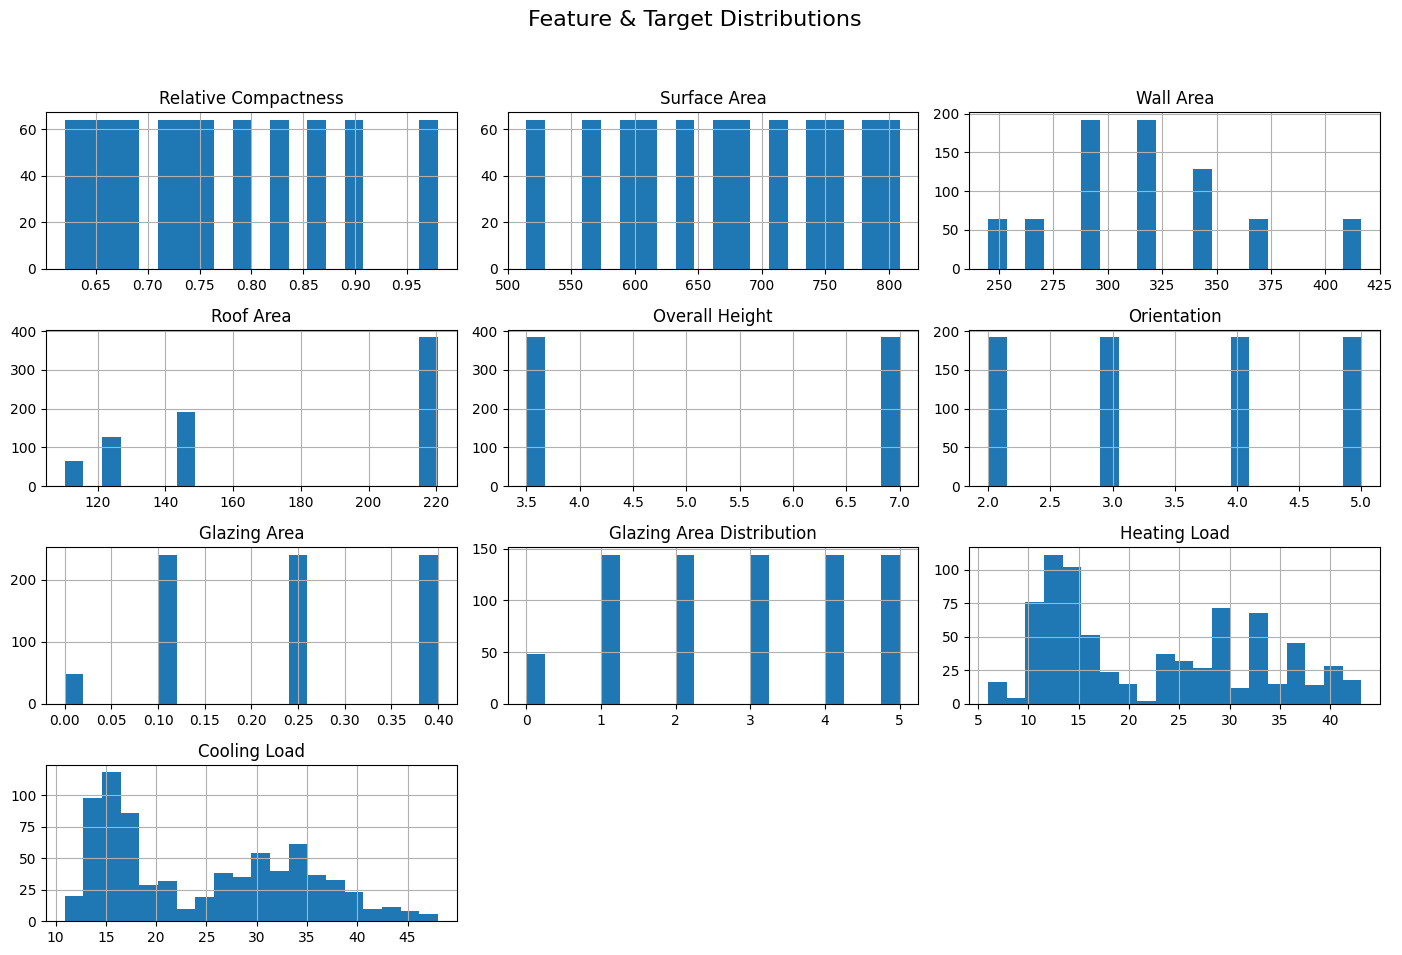

In [ ]:
# ---------- EDA: Histograms of features & targets ----------
features = [
    'Relative Compactness', 'Surface Area', 'Wall Area', 'Roof Area',
    'Overall Height', 'Orientation', 'Glazing Area', 'Glazing Area Distribution'
]

plt.figure(figsize=(14, 10))
df[features + ['Heating Load', 'Cooling Load']].hist(bins=20, figsize=(14, 10))
plt.suptitle("Feature & Target Distributions", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

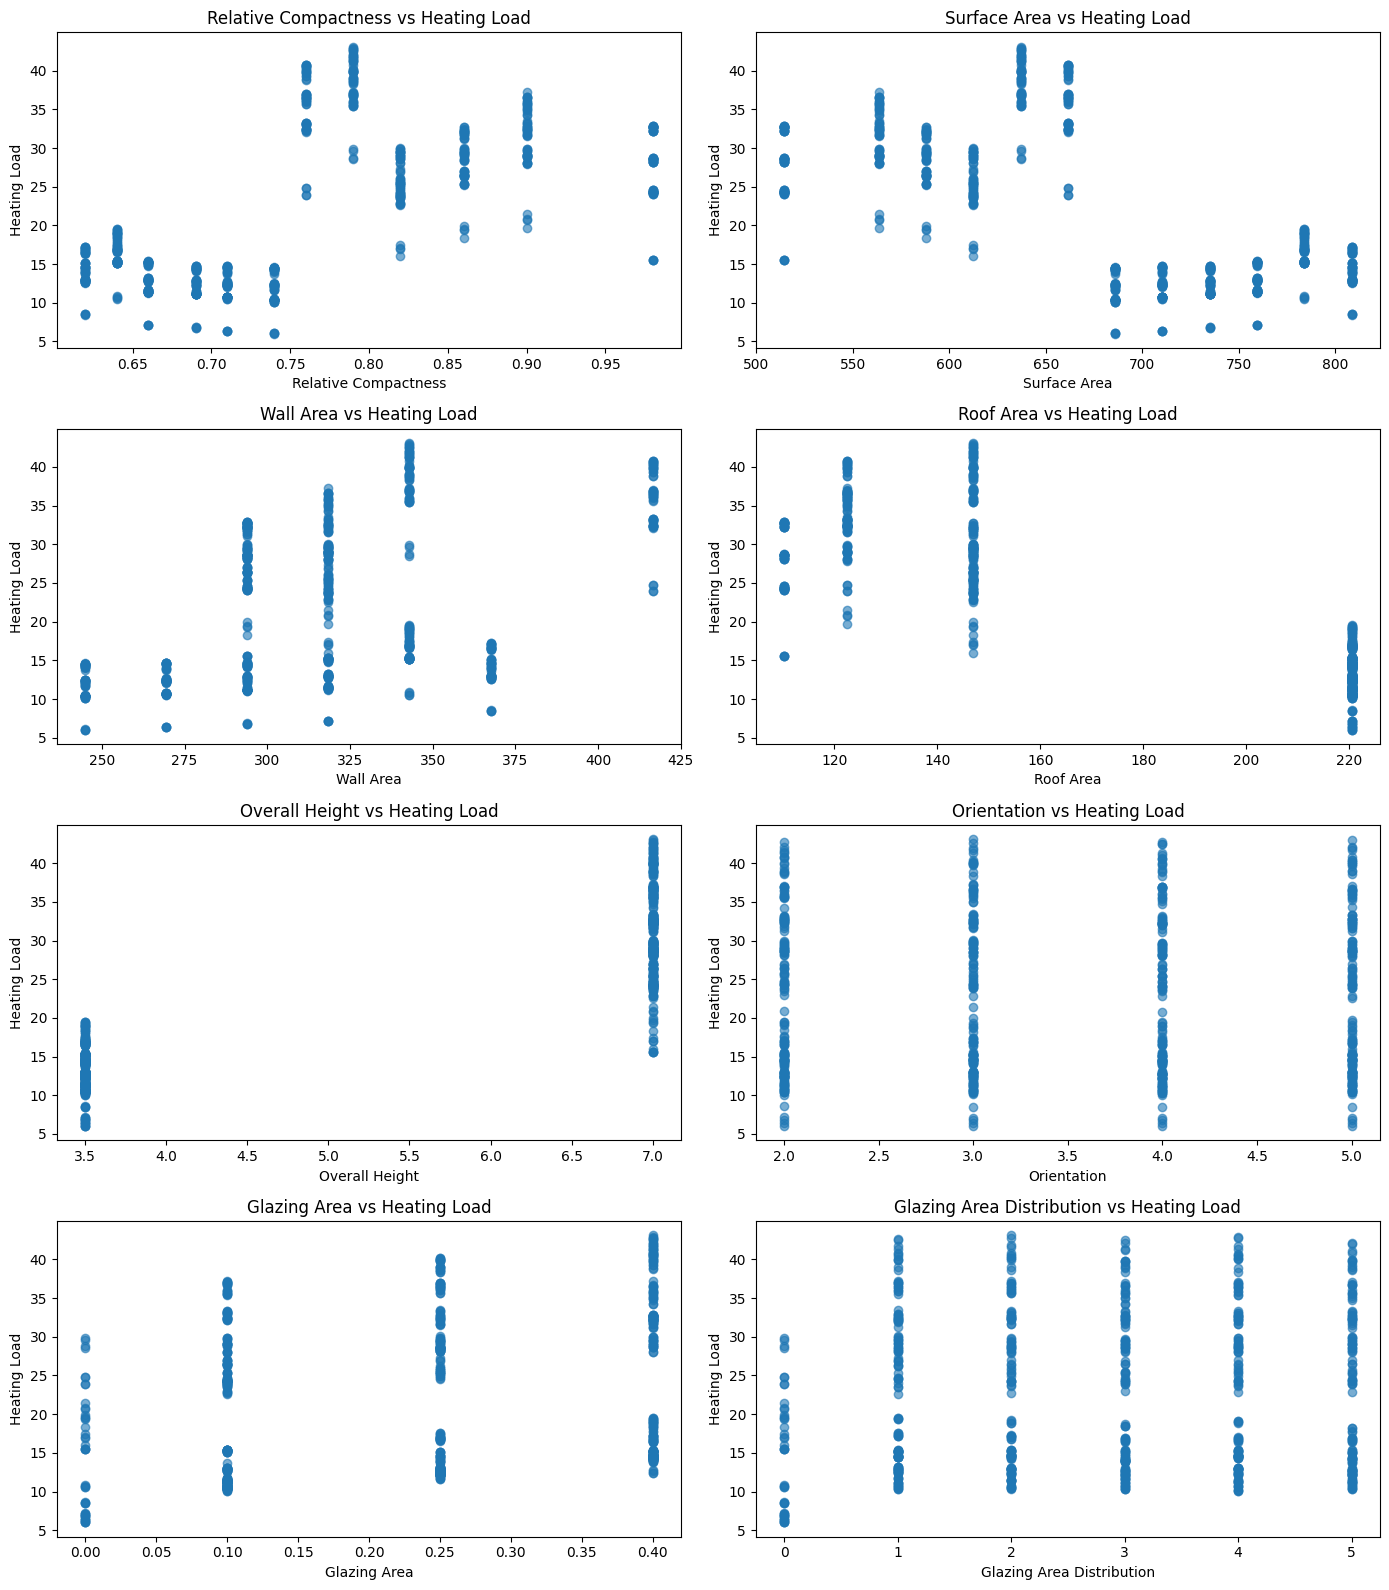

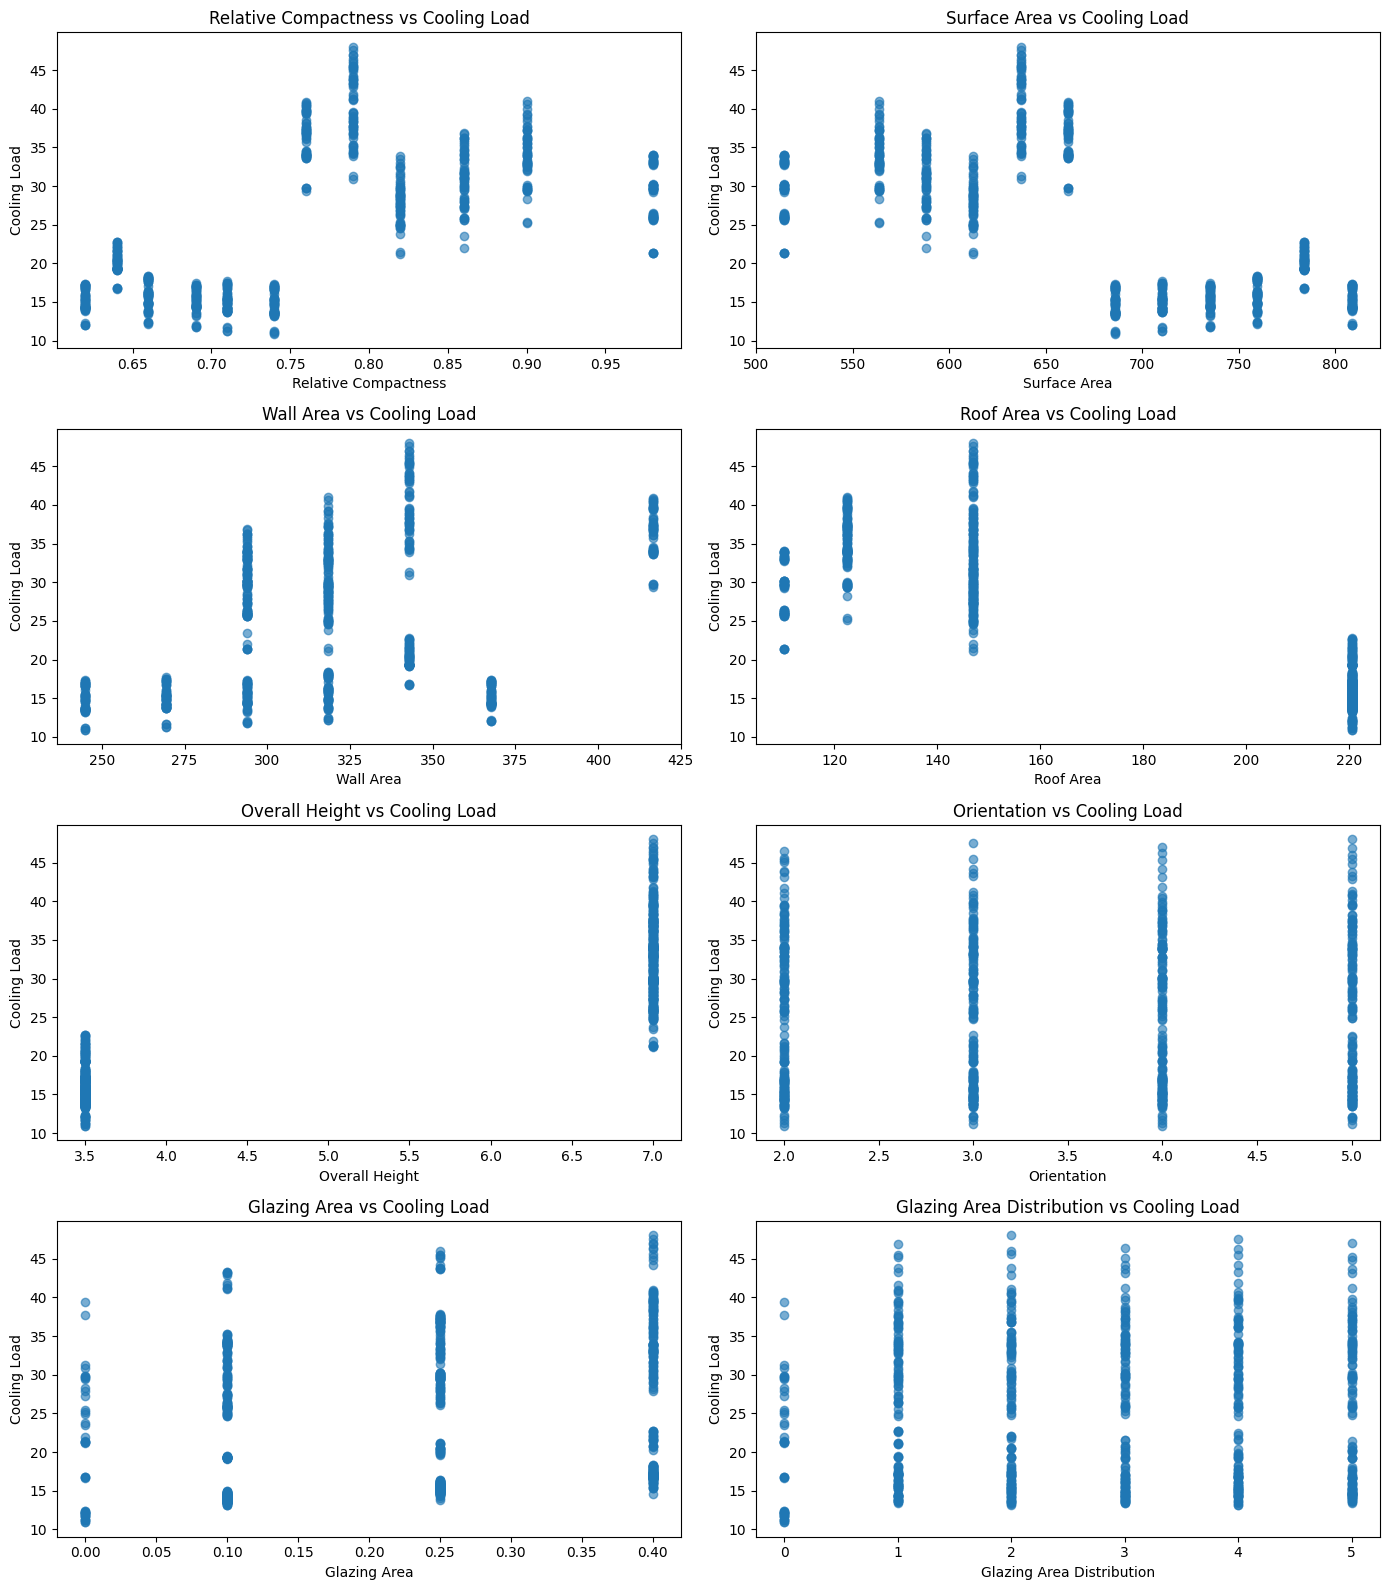

In [ ]:
# ---------- EDA: scatter plots feature vs Heating and Cooling ----------
def scatter_features_vs_target(df, feature_list, target, ncols=2, figsize=(14, 16)):
    n = len(feature_list)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)
    axes = axes.flatten()
    for i, f in enumerate(feature_list):
        axes[i].scatter(df[f], df[target], alpha=0.6)
        axes[i].set_xlabel(f)
        axes[i].set_ylabel(target)
        axes[i].set_title(f"{f} vs {target}")
    # hide unused axes
    for j in range(i+1, len(axes)):
        axes[j].axis('off')
    plt.tight_layout()
    plt.show()

scatter_features_vs_target(df, features, 'Heating Load', figsize=(14, 16))
scatter_features_vs_target(df, features, 'Cooling Load', figsize=(14, 16))

In [ ]:
# ---------- Prepare data ----------
X = df[features].values
y_heating = df['Heating Load'].values
y_cooling = df['Cooling Load'].values

# Scale features (important for regularized models)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train/test split (same split for both targets)
X_train, X_test, y1_train, y1_test = train_test_split(X_scaled, y_heating, test_size=0.2, random_state=42)
# For cooling copy the split indices so both use same train/test samples
# We'll get the indices by comparing shapes (easier approach: use the same random_state with function)
# But to be sure, do a second split with same random_state and test_size and same X_scaled
_, _, y2_train, y2_test = train_test_split(X_scaled, y_cooling, test_size=0.2, random_state=42)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Train shape: (614, 8) Test shape: (154, 8)


In [ ]:
# ---------- Models setup ----------
# We'll use RidgeCV and LassoCV to find good alpha (regularization strength).
alphas = np.logspace(-3, 3, 50)

models = {
    'Linear': LinearRegression(),
    'RidgeCV': RidgeCV(alphas=alphas, store_cv_values=True),
    'LassoCV': LassoCV(alphas=alphas, cv=5, max_iter=5000)
}

In [ ]:
# ---------- Training & Evaluation function ----------
def train_and_evaluate(models, X_train, X_test, y_train, y_test, feature_names, target_name):
    results = {}
    for name, model in models.items():
        # Fit
        model.fit(X_train, y_train)
        # Predict
        y_pred = model.predict(X_test)
        y_train_pred = model.predict(X_train)
        # Metrics
        mse_test = mean_squared_error(y_test, y_pred)
        r2_test = r2_score(y_test, y_pred)
        mse_train = mean_squared_error(y_train, y_train_pred)
        r2_train = r2_score(y_train, y_train_pred)

        # Coefficients (map back to feature scale)
        if hasattr(model, 'coef_'):
            coefs = model.coef_
        else:
            coefs = None

        # If RidgeCV or LassoCV, get selected alpha
        alpha = getattr(model, 'alpha_', None)

        results[name] = {
            'model': model,
            'y_pred': y_pred,
            'mse_test': mse_test,
            'r2_test': r2_test,
            'mse_train': mse_train,
            'r2_train': r2_train,
            'coefs': coefs,
            'alpha': alpha
        }

        # Print summary
        print(f"\n--- {target_name} : {name} ---")
        print(f"Train MSE: {mse_train:.4f}, Train R2: {r2_train:.4f}")
        print(f"Test  MSE: {mse_test:.4f}, Test  R2: {r2_test:.4f}")
        if alpha is not None:
            print(f"Chosen alpha: {alpha}")
        if coefs is not None:
            # show coefficients alongside feature names
            coef_table = pd.DataFrame({
                'feature': feature_names,
                'coefficient': coefs
            }).sort_values(by='coefficient', key=abs, ascending=False)
            display(coef_table)

        # Plot predicted vs actual
        plt.figure(figsize=(6,4))
        plt.scatter(y_test, y_pred, alpha=0.6)
        plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle='--')
        plt.xlabel("Actual " + target_name)
        plt.ylabel("Predicted " + target_name)
        plt.title(f"{name} - Actual vs Predicted ({target_name})")
        plt.tight_layout()
        plt.show()

        # Residuals plot
        residuals = y_test - y_pred
        plt.figure(figsize=(6,4))
        plt.scatter(y_pred, residuals, alpha=0.6)
        plt.axhline(0, linestyle='--')
        plt.xlabel("Predicted " + target_name)
        plt.ylabel("Residuals")
        plt.title(f"{name} - Residuals ({target_name})")
        plt.tight_layout()
        plt.show()

    return results


==== TRAINING for Heating Load ====

--- Heating Load : Linear ---
Train MSE: 8.3701, Train R2: 0.9171
Test  MSE: 9.1532, Test  R2: 0.9122


,feature,coefficient
4,Overall Height,7.216421
0,Relative Compactness,-6.540545
3,Roof Area,-3.919164
1,Surface Area,-3.618459
6,Glazing Area,2.681740
2,Wall Area,0.808902
7,Glazing Area Distribution,0.327199
5,Orientation,-0.036268


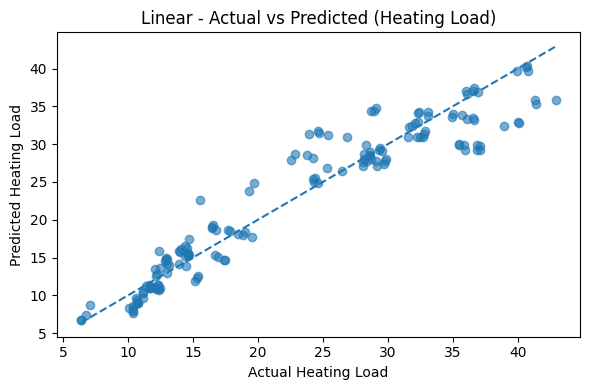

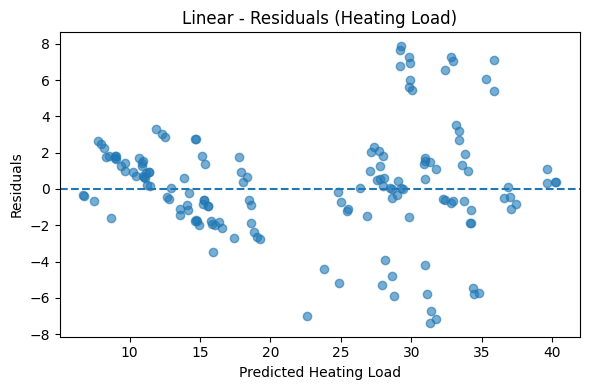


--- Heating Load : RidgeCV ---
Train MSE: 8.3704, Train R2: 0.9171
Test  MSE: 9.1601, Test  R2: 0.9121
Chosen alpha: 0.1206792640639329


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_ridge.py:2385: FutureWarning: 'store_cv_values' is deprecated in version 1.5 and will be removed in 1.7. Use 'store_cv_results' instead.
  warnings.warn(


,feature,coefficient
4,Overall Height,7.265050
0,Relative Compactness,-6.362573
3,Roof Area,-3.815040
1,Surface Area,-3.497350
6,Glazing Area,2.681765
2,Wall Area,0.837836
7,Glazing Area Distribution,0.327420
5,Orientation,-0.036169


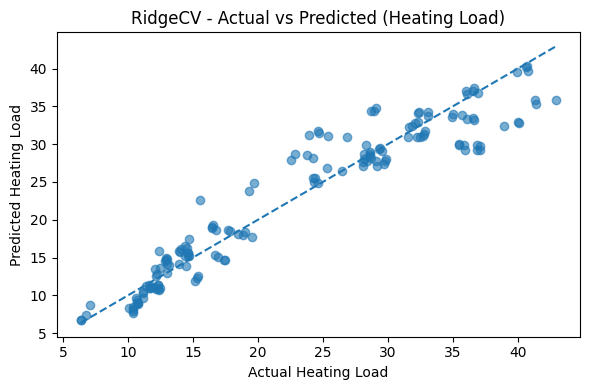

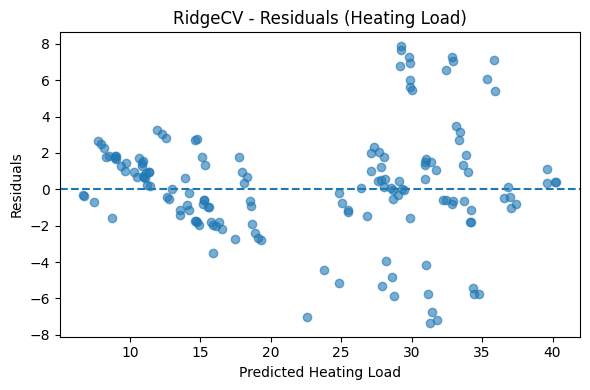


--- Heating Load : LassoCV ---
Train MSE: 8.3704, Train R2: 0.9171
Test  MSE: 9.1582, Test  R2: 0.9121
Chosen alpha: 0.001


,feature,coefficient
4,Overall Height,7.275573
1,Surface Area,-6.377144
0,Relative Compactness,-6.369395
6,Glazing Area,2.681397
2,Wall Area,2.260042
3,Roof Area,-0.858355
7,Glazing Area Distribution,0.326572
5,Orientation,-0.035018


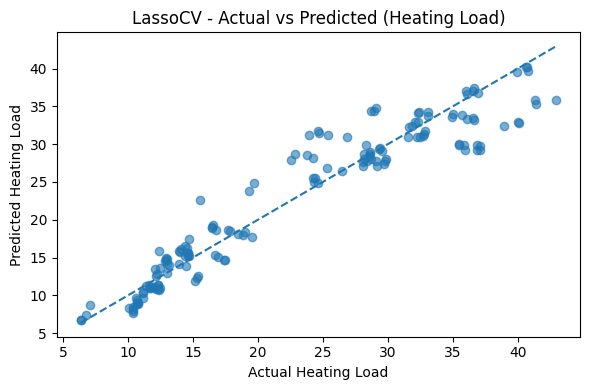

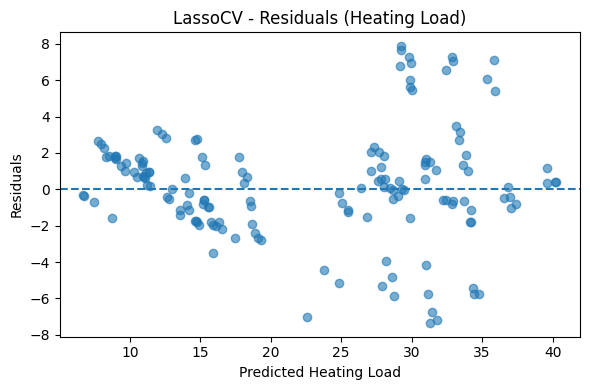

In [ ]:
# ---------- Train & Evaluate for Heating Load ----------
print("\n==== TRAINING for Heating Load ====")
results_heating = train_and_evaluate(models, X_train, X_test, y1_train, y1_test, features, "Heating Load")


==== TRAINING for Cooling Load ====

--- Cooling Load : Linear ---
Train MSE: 10.2282, Train R2: 0.8859
Test  MSE: 9.8934, Test  R2: 0.8932


,feature,coefficient
0,Relative Compactness,-7.514245
4,Overall Height,7.080781
1,Surface Area,-4.155150
3,Roof Area,-4.123546
6,Glazing Area,1.968728
2,Wall Area,0.148460
5,Orientation,0.061727
7,Glazing Area Distribution,0.052296


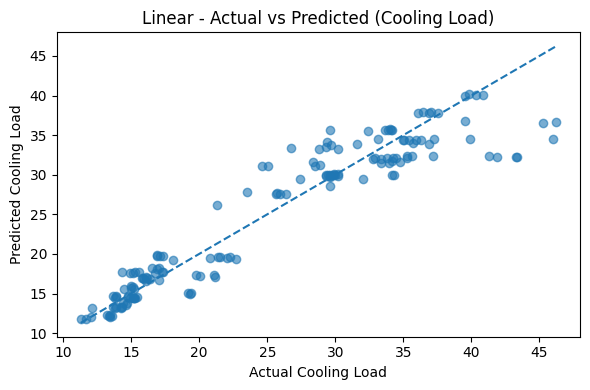

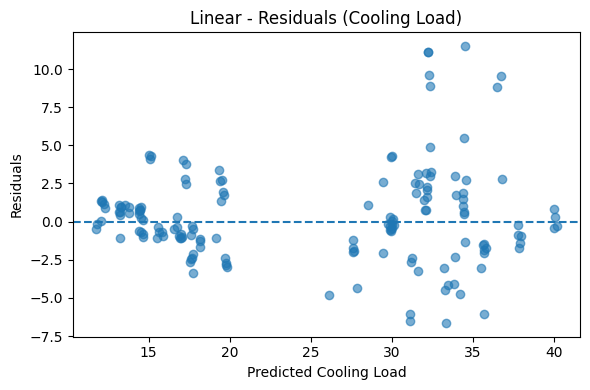


--- Cooling Load : RidgeCV ---
Train MSE: 10.2286, Train R2: 0.8859
Test  MSE: 9.8961, Test  R2: 0.8932
Chosen alpha: 0.1206792640639329


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_ridge.py:2385: FutureWarning: 'store_cv_values' is deprecated in version 1.5 and will be removed in 1.7. Use 'store_cv_results' instead.
  warnings.warn(


,feature,coefficient
0,Relative Compactness,-7.303839
4,Overall Height,7.141759
1,Surface Area,-4.010434
3,Roof Area,-3.998666
6,Glazing Area,1.968985
2,Wall Area,0.182080
5,Orientation,0.061845
7,Glazing Area Distribution,0.052590


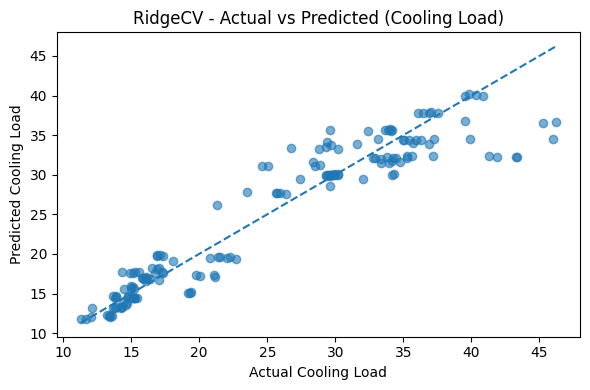

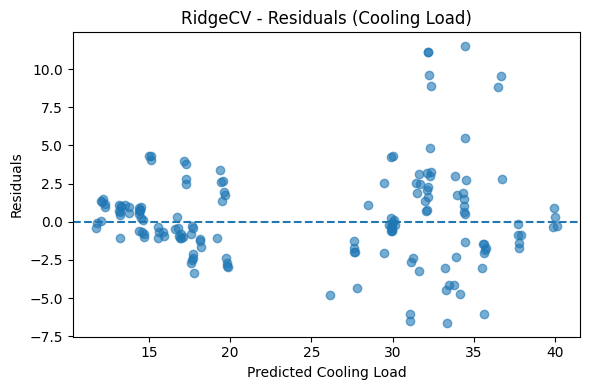


--- Cooling Load : LassoCV ---
Train MSE: 10.2285, Train R2: 0.8859
Test  MSE: 9.8942, Test  R2: 0.8932
Chosen alpha: 0.001


,feature,coefficient
0,Relative Compactness,-7.344542
1,Surface Area,-7.184973
4,Overall Height,7.139037
6,Glazing Area,1.968438
2,Wall Area,1.733194
3,Roof Area,-0.787025
5,Orientation,0.060932
7,Glazing Area Distribution,0.051675


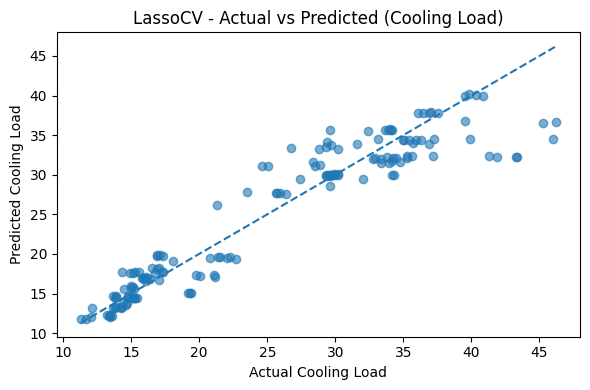

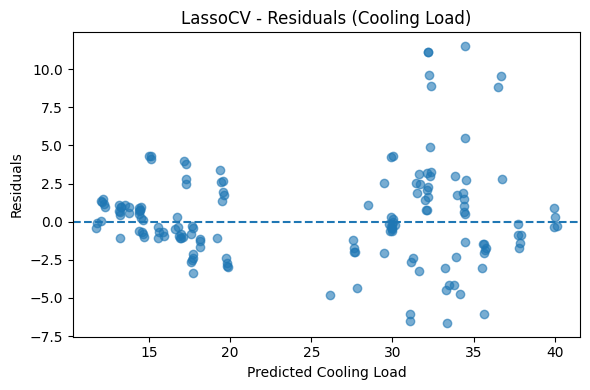

In [ ]:
# ---------- Train & Evaluate for Cooling Load ----------
print("\n==== TRAINING for Cooling Load ====")
results_cooling = train_and_evaluate(models, X_train, X_test, y2_train, y2_test, features, "Cooling Load")

In [ ]:
# ---------- Quick predictions example (first 5 test samples) ----------
print("\nSample Predictions (first 5 test rows):")
sample_X = X_test[:5]
for tname, results in [('Heating Load', results_heating), ('Cooling Load', results_cooling)]:
    print(f"\n--- {tname} ---")
    for model_name, res in results.items():
        preds = res['y_pred'][:5]
        print(f"{model_name} preds:", np.round(preds, 3))


Sample Predictions (first 5 test rows):

--- Heating Load ---
Linear preds: [18.863 14.049 31.316 35.901 15.335]
RidgeCV preds: [18.893 14.047 31.342 35.893 15.349]
LassoCV preds: [18.889 14.046 31.333 35.897 15.347]

--- Cooling Load ---
Linear preds: [19.755 16.772 32.025 36.702 17.277]
RidgeCV preds: [19.791 16.768 32.055 36.695 17.293]
LassoCV preds: [19.783 16.771 32.046 36.697 17.289]


In [ ]:
# ---------- Summary table for test metrics ----------
def summary_table(results_dict):
    rows = []
    for name, r in results_dict.items():
        rows.append({
            'Model': name,
            'Test MSE': r['mse_test'],
            'Test R2': r['r2_test'],
            'Alpha': r['alpha'] if r['alpha'] is not None else '-'
        })
    return pd.DataFrame(rows).sort_values('Test MSE')

print("\nHeating summary:")
display(summary_table(results_heating))
print("\nCooling summary:")
display(summary_table(results_cooling))


Heating summary:


,Model,Test MSE,Test R2,Alpha
0,Linear,9.153188,0.912184,-
2,LassoCV,9.158178,0.912136,0.001
1,RidgeCV,9.160139,0.912117,0.120679



Cooling summary:


,Model,Test MSE,Test R2,Alpha
0,Linear,9.893428,0.893226,-
2,LassoCV,9.894220,0.893217,0.001
1,RidgeCV,9.896060,0.893197,0.120679


In [ ]:
# ---------- Save scaler & best models if desired ----------
# Example: save models using joblib
# import joblib
# joblib.dump(scaler, "scaler.pkl")
# joblib.dump(results_heating['RidgeCV']['model'], "ridge_heating_model.pkl")

print("\nDone. You can change alpha ranges, use GridSearchCV, or add polynomial features if you want to improve performance.")


Done. You can change alpha ranges, use GridSearchCV, or add polynomial features if you want to improve performance.


In [ ]:
# ---------- Manual Input Prediction ----------

# Example manual input (change values as needed)
manual_input = {
    "Relative Compactness": 0.85,
    "Surface Area": 750.0,
    "Wall Area": 300.0,
    "Roof Area": 150.0,
    "Overall Height": 7.0,
    "Orientation": 3,
    "Glazing Area": 0.1,
    "Glazing Area Distribution": 3
}

print("Manual input values:")
for k,v in manual_input.items():
    print(f"{k}: {v}")

# Convert to DataFrame
manual_df = pd.DataFrame([manual_input])

# Scale using the same scaler
manual_scaled = scaler.transform(manual_df[features])

# Predictions for Heating & Cooling from each model
print("\n=== Predictions for Manual Input ===")

for target_name, results in [("Heating Load", results_heating), ("Cooling Load", results_cooling)]:
    print(f"\n--- {target_name} ---")
    for model_name, res in results.items():
        pred_val = res['model'].predict(manual_scaled)[0]
        print(f"{model_name}: {pred_val:.3f}")


Manual input values:
Relative Compactness: 0.85
Surface Area: 750.0
Wall Area: 300.0
Roof Area: 150.0
Overall Height: 7.0
Orientation: 3
Glazing Area: 0.1
Glazing Area Distribution: 3

=== Predictions for Manual Input ===

--- Heating Load ---
Linear: 22.158
RidgeCV: 22.430
LassoCV: 17.020

--- Cooling Load ---
Linear: 22.158
RidgeCV: 22.430
LassoCV: 17.020


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


## Different Types of Regression


In [ ]:
# ---------- Imports for new regressors ----------
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [ ]:
# ---------- Models setup ----------
# We'll use RidgeCV and LassoCV to find good alpha (regularization strength).
alphas = np.logspace(-3, 3, 50)

models = {
    'LinearRegression': LinearRegression(),
    'RidgeCV': RidgeCV(alphas=alphas, store_cv_values=True),
    'LassoCV': LassoCV(alphas=alphas, cv=5, max_iter=5000),
    'DecisionTree': DecisionTreeRegressor(max_depth=6, random_state=42),
    'RandomForest': RandomForestRegressor(n_estimators=100, max_depth=6, random_state=42)
}

In [ ]:
# ---------- Training & Evaluation function ----------
def train_and_evaluate(models, X_train, X_test, y_train, y_test, feature_names, target_name):
    results = {}
    for name, model in models.items():
        # Fit
        model.fit(X_train, y_train)
        # Predict
        y_pred = model.predict(X_test)
        y_train_pred = model.predict(X_train)

        # Metrics
        mse_test = mean_squared_error(y_test, y_pred)
        r2_test = r2_score(y_test, y_pred)
        mse_train = mean_squared_error(y_train, y_train_pred)
        r2_train = r2_score(y_train, y_train_pred)

        results[name] = {
            'model': model,
            'y_pred': y_pred,
            'mse_test': mse_test,
            'r2_test': r2_test,
            'mse_train': mse_train,
            'r2_train': r2_train,
        }

        # Print summary
        print(f"\n--- {target_name} : {name} ---")
        print(f"Train MSE: {mse_train:.4f}, Train R2: {r2_train:.4f}")
        print(f"Test  MSE: {mse_test:.4f}, Test  R2: {r2_test:.4f}")

        # Plot predicted vs actual
        plt.figure(figsize=(6,4))
        plt.scatter(y_test, y_pred, alpha=0.6)
        plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle='--')
        plt.xlabel("Actual " + target_name)
        plt.ylabel("Predicted " + target_name)
        plt.title(f"{name} - Actual vs Predicted ({target_name})")
        plt.tight_layout()
        plt.show()

    return results


==== TRAINING for Heating Load ====

--- Heating Load : LinearRegression ---
Train MSE: 8.3701, Train R2: 0.9171
Test  MSE: 9.1532, Test  R2: 0.9122


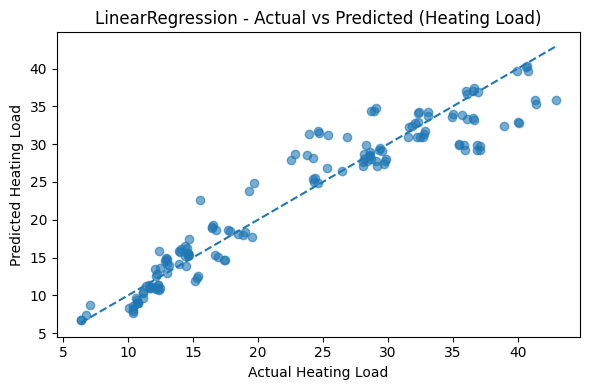


--- Heating Load : RidgeCV ---
Train MSE: 8.3704, Train R2: 0.9171
Test  MSE: 9.1601, Test  R2: 0.9121


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_ridge.py:2385: FutureWarning: 'store_cv_values' is deprecated in version 1.5 and will be removed in 1.7. Use 'store_cv_results' instead.
  warnings.warn(


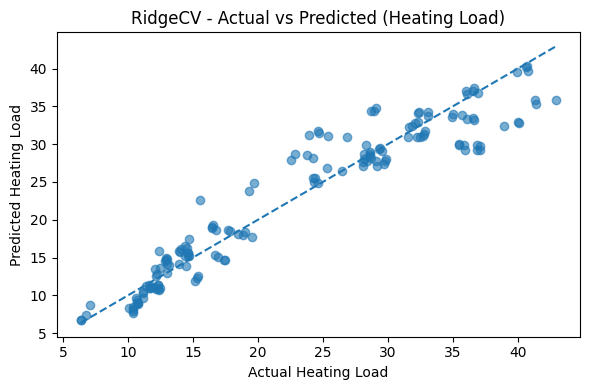


--- Heating Load : LassoCV ---
Train MSE: 8.3704, Train R2: 0.9171
Test  MSE: 9.1582, Test  R2: 0.9121


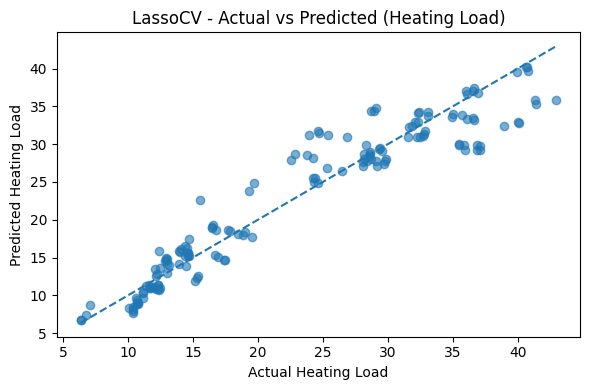


--- Heating Load : DecisionTree ---
Train MSE: 0.2342, Train R2: 0.9977
Test  MSE: 0.3336, Test  R2: 0.9968


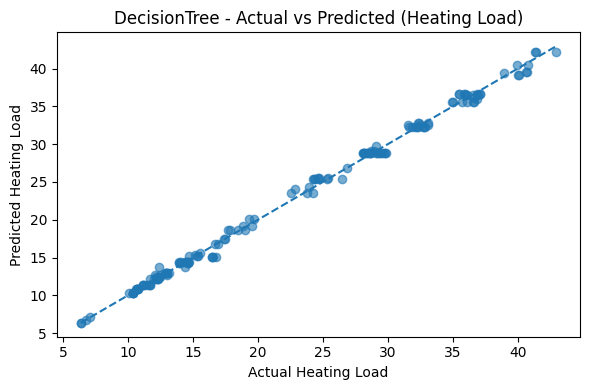


--- Heating Load : RandomForest ---
Train MSE: 0.2028, Train R2: 0.9980
Test  MSE: 0.2988, Test  R2: 0.9971


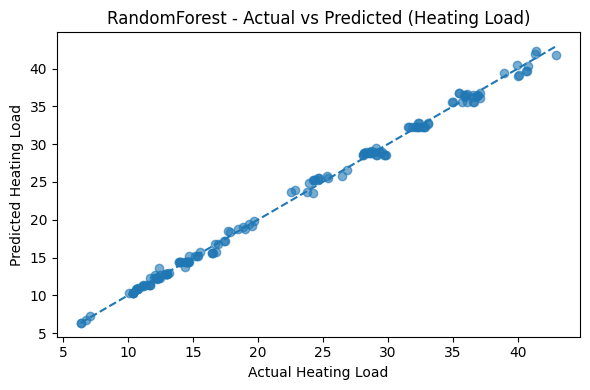

In [ ]:
# ---------- Train & Evaluate for Heating Load ----------
print("\n==== TRAINING for Heating Load ====")
results_heating = train_and_evaluate(models, X_train, X_test, y1_train, y1_test, features, "Heating Load")


==== TRAINING for Cooling Load ====

--- Cooling Load : LinearRegression ---
Train MSE: 10.2282, Train R2: 0.8859
Test  MSE: 9.8934, Test  R2: 0.8932


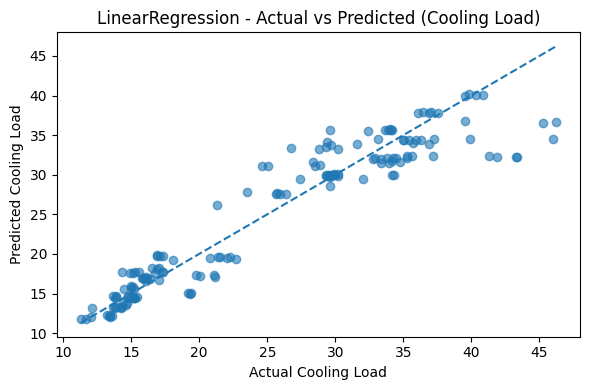


--- Cooling Load : RidgeCV ---
Train MSE: 10.2286, Train R2: 0.8859
Test  MSE: 9.8961, Test  R2: 0.8932


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_ridge.py:2385: FutureWarning: 'store_cv_values' is deprecated in version 1.5 and will be removed in 1.7. Use 'store_cv_results' instead.
  warnings.warn(


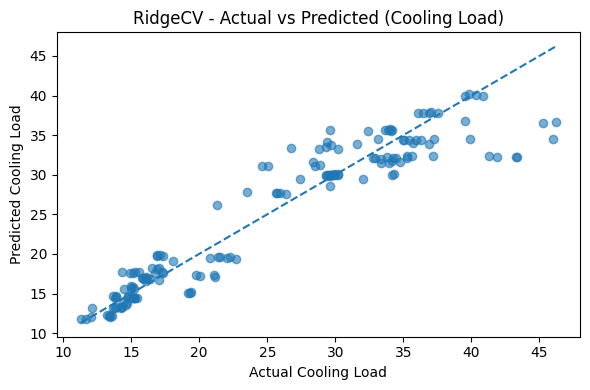


--- Cooling Load : LassoCV ---
Train MSE: 10.2285, Train R2: 0.8859
Test  MSE: 9.8942, Test  R2: 0.8932


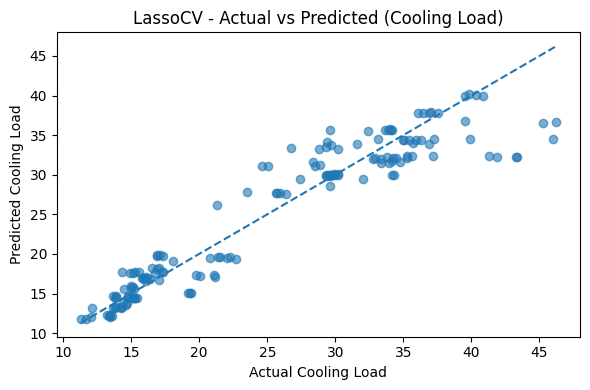


--- Cooling Load : DecisionTree ---
Train MSE: 2.1927, Train R2: 0.9755
Test  MSE: 3.5537, Test  R2: 0.9616


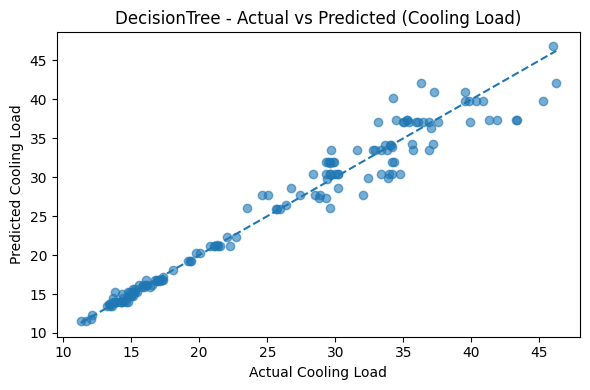


--- Cooling Load : RandomForest ---
Train MSE: 1.8847, Train R2: 0.9790
Test  MSE: 3.2042, Test  R2: 0.9654


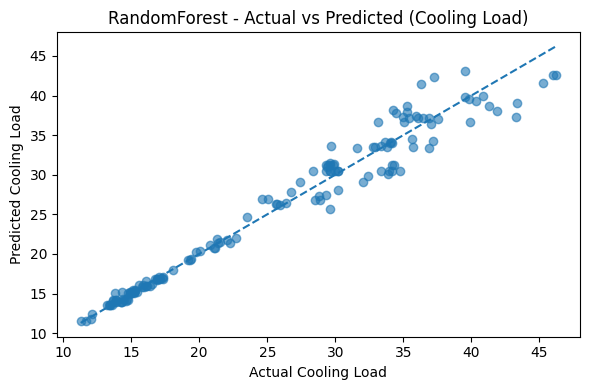

In [ ]:
# ---------- Train & Evaluate for Cooling Load ----------
print("\n==== TRAINING for Cooling Load ====")
results_cooling = train_and_evaluate(models, X_train, X_test, y2_train, y2_test, features, "Cooling Load")

In [ ]:
# ---------- Summary table ----------
def summary_table(results_dict):
    rows = []
    for name, r in results_dict.items():
        rows.append({
            'Model': name,
            'Test MSE': r['mse_test'],
            'Test R2': r['r2_test'],
        })
    return pd.DataFrame(rows).sort_values('Test MSE')

print("\nHeating summary:")
display(summary_table(results_heating))
print("\nCooling summary:")
display(summary_table(results_cooling))


Heating summary:


,Model,Test MSE,Test R2
4,RandomForest,0.298817,0.997133
3,DecisionTree,0.333637,0.996799
0,LinearRegression,9.153188,0.912184
2,LassoCV,9.158178,0.912136
1,RidgeCV,9.160139,0.912117



Cooling summary:


,Model,Test MSE,Test R2
4,RandomForest,3.204249,0.965418
3,DecisionTree,3.553675,0.961647
0,LinearRegression,9.893428,0.893226
2,LassoCV,9.894220,0.893217
1,RidgeCV,9.896060,0.893197


In [ ]:
# ---------- Manual input prediction for the 3 models (both targets) ----------
# Make sure this cell runs after training so that:
# - scaler is fitted
# - features list exists
# - results_heating and results_cooling dicts exist (from train_and_evaluate)

# Use the same manual values as before (change if needed)
manual_input = {
    "Relative Compactness": 0.85,
    "Surface Area": 750.0,
    "Wall Area": 300.0,
    "Roof Area": 150.0,
    "Overall Height": 7.0,
    "Orientation": 3,
    "Glazing Area": 0.1,
    "Glazing Area Distribution": 3
}

# Display input
print("Manual input values:")
for k, v in manual_input.items():
    print(f"  {k}: {v}")

# Convert to DataFrame (order of columns must match 'features')
manual_df = pd.DataFrame([manual_input])[features]

# Scale using the same scaler used for training
manual_scaled = scaler.transform(manual_df)

# Function to print predictions for a results dict (heating/cooling)
def print_manual_predictions(results_dict, target_name):
    print(f"\n=== Predictions for {target_name} ===")
    for model_name, res in results_dict.items():
        model = res['model']
        # Some tree models might accept 2D arrays directly; we already have manual_scaled as 2D
        pred = model.predict(manual_scaled)[0]
        # If you want rounded output:
        print(f"{model_name:15s} -> {pred:.3f}")

# Print for Heating Load
print_manual_predictions(results_heating, "Heating Load")

# Print for Cooling Load
print_manual_predictions(results_cooling, "Cooling Load")


Manual input values:
  Relative Compactness: 0.85
  Surface Area: 750.0
  Wall Area: 300.0
  Roof Area: 150.0
  Overall Height: 7.0
  Orientation: 3
  Glazing Area: 0.1
  Glazing Area Distribution: 3

=== Predictions for Heating Load ===
LinearRegression -> 22.158
RidgeCV         -> 22.430
LassoCV         -> 17.020
DecisionTree    -> 34.106
RandomForest    -> 30.012

=== Predictions for Cooling Load ===
LinearRegression -> 22.158
RidgeCV         -> 22.430
LassoCV         -> 17.020
DecisionTree    -> 34.106
RandomForest    -> 30.012


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


## Exporting the models

In [ ]:
# ---------- Exporting the models ----------
import joblib
import os

# Create a directory to save the models if it doesn't exist
if not os.path.exists("exported_models"):
    os.makedirs("exported_models")

# Save the scaler
joblib.dump(scaler, "exported_models/scaler.pkl")
print("Scaler exported to exported_models/scaler.pkl")

# Save each trained model
for target_name, results in [("Heating Load", results_heating), ("Cooling Load", results_cooling)]:
    for model_name, res in results.items():
        model = res['model']
        filename = f"exported_models/{target_name.replace(' ', '_').lower()}_{model_name.lower()}.pkl"
        joblib.dump(model, filename)
        print(f"Model '{model_name}' for '{target_name}' exported to {filename}")

Scaler exported to exported_models/scaler.pkl
Model 'LinearRegression' for 'Heating Load' exported to exported_models/heating_load_linearregression.pkl
Model 'RidgeCV' for 'Heating Load' exported to exported_models/heating_load_ridgecv.pkl
Model 'LassoCV' for 'Heating Load' exported to exported_models/heating_load_lassocv.pkl
Model 'DecisionTree' for 'Heating Load' exported to exported_models/heating_load_decisiontree.pkl
Model 'RandomForest' for 'Heating Load' exported to exported_models/heating_load_randomforest.pkl
Model 'LinearRegression' for 'Cooling Load' exported to exported_models/cooling_load_linearregression.pkl
Model 'RidgeCV' for 'Cooling Load' exported to exported_models/cooling_load_ridgecv.pkl
Model 'LassoCV' for 'Cooling Load' exported to exported_models/cooling_load_lassocv.pkl
Model 'DecisionTree' for 'Cooling Load' exported to exported_models/cooling_load_decisiontree.pkl
Model 'RandomForest' for 'Cooling Load' exported to exported_models/cooling_load_randomforest.pk